![OneHealth DataSpace](https://bigdata.dataspace.cesga.es/static/images/public/imagotipo.png)

# Validacion del modelo ROMS

In [1]:
from pyspark.sql.functions import col, expr, date_format
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import onehealth
onehealth.list()

Dataset,Proveedor,Descripción,ID
modelos/wrf_1km,MeteoGalicia,Datos del modelo WRF de MeteoGalicia en resolución de 1km,664623db9e787d70126d1c53
modelos/meteogalicia_roms,MeteoGalicia,Datos del modelo ROMS de MeteoGalicia con una resolución espacial de 2 km,6646249f9e787d70126d1c54
modelos/ieo_roms,IEO,Datos del modelo ROMS de IEO con una resolución espacial de 4 km,6646259a9e787d70126d1c55
modelos/wrf_4km,MeteoGalicia,Datos del modelo WRF de MeteoGalicia en resolución de 4km,6662ecf8f7e452764784d22e
modelos/wrf_5km,MeteoGalicia,Datos del modelo WRF de MeteoGalicia en resolución de 5km,6662ed06f7e452764784d22f
afloramento/intecmar_calculo,INTECMAR,Datos para el cálculo del índice de afloramiento,6645fe019e787d70126d1c45
afloramento/intecmar_hfrui,INTECMAR,Mapas del índice de afloramiento costero a lo largo de la costa del norte de Portugal y Galicia,6646210f9e787d70126d1c4d
afloramento/ieo_ui,IEO,"Contiene datos relacionados con el índice de afloramiento costero, proporcionado por el Instituto Español de Oceanografía",664627589e787d70126d1c57
afloramento/csic_arios,CSIC,Una base de datos Oceánica sobre Acidificación para el Ecosistema de Afloramiento Gallego,66462be49e787d70126d1c62
physalia_physalis/Simulaciones OpenDrift de Physalia Physalis,IEO,Simulaciones de deriva mediante OpenDrift con miles de partículas virtuales que representan posibles carabelas portuguesas frente a la costa gallega.,6a6892877d543dc1360760bf


Procesamos los datos de la boya

In [3]:
cies = onehealth.load('BfoCid79Q5Gax9g').filter( (col('MEDIDA') == 'Temperatura (Superficie)') & (col('CODIGO_VALIDACION') != '9') ).toPandas()
cies.set_index('DATA',inplace=True)
cies.index = pd.to_datetime(cies.index,dayfirst=True)

cies.VALOR = cies.VALOR.apply(lambda x : x.replace(',','.')).astype('float')

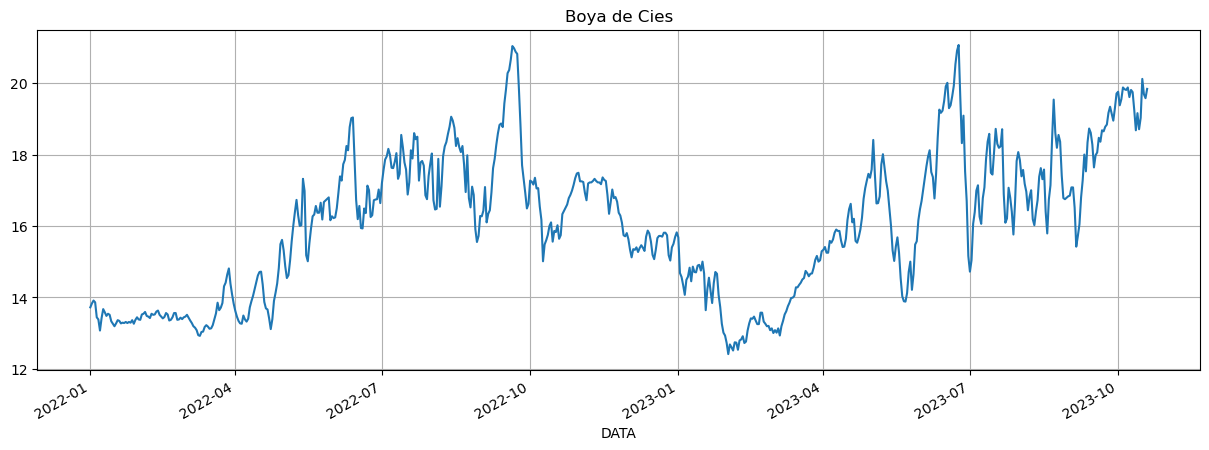

In [4]:
plt.figure(figsize=(15,5))
cies.VALOR.plot()
plt.title('Boya de Cies')
plt.grid()

Cargamos los datos del modelo. Usamos una particion pequeña de un año de datos (2022). El filtrado lo hacemos por profundidad y por STEP, que es el horizonte de prediccion. Nos quedamos con el resto de los indices, espaciales (lon_rho, lat_rho) y temporales (ocean_time):

In [5]:
df = onehealth.load_partition("DmTYeZYxD5wfRax", 2022)
filtrado = df.filter( (col('depth')==0) & (col('step')<=23) ).select(['ocean_time','lon_rho','lat_rho','temp'])
filtrado.show()

26/08/13 15:20:38 WARN datasources.DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Consider to choose another name or rename the existing column.


+-------------------+-------+-------+------------------+
|         ocean_time|lon_rho|lat_rho|              temp|
+-------------------+-------+-------+------------------+
|2022-01-26 05:00:00|  -14.0|   38.0|17.226219177246094|
|2022-01-26 05:00:00| -13.98|   38.0|17.227352142333984|
|2022-01-26 05:00:00| -13.96|   38.0| 17.20962142944336|
|2022-01-26 05:00:00| -13.94|   38.0|17.217851638793945|
|2022-01-26 05:00:00| -13.92|   38.0| 17.20933723449707|
|2022-01-26 05:00:00|  -13.9|   38.0|17.223846435546875|
|2022-01-26 05:00:00| -13.88|   38.0|17.212980270385742|
|2022-01-26 05:00:00| -13.86|   38.0|  17.1737060546875|
|2022-01-26 05:00:00| -13.84|   38.0|17.155929565429688|
|2022-01-26 05:00:00| -13.82|   38.0| 17.12794303894043|
|2022-01-26 05:00:00|  -13.8|   38.0|  17.0987606048584|
|2022-01-26 05:00:00| -13.78|   38.0|17.024328231811523|
|2022-01-26 05:00:00| -13.76|   38.0|16.965944290161133|
|2022-01-26 05:00:00| -13.74|   38.0|16.935195922851562|
|2022-01-26 05:00:00| -13.72|  

Obtenemos los datos de un instante concreto para reconstruir la malla y la matriz de temperaturas:

In [6]:
# Obtenemos la columna temperatura:
valores = filtrado.filter( (col('ocean_time') == '2022-06-01 12:00:00') ).select(['lon_rho','lat_rho','temp']).toPandas().values

# Tamaño 401*476:
lon  = valores[:,0].reshape((401,476))
lat  = valores[:,1].reshape((401,476))
T  = valores[:,2].reshape((401,476))

La malla del ROMS usa coordenadas esfericas/geograficas (no proyectadas), por lo tanto no es necesario retener las dos dimensiones de lon y lat:

In [7]:
lon = lon[0,:]
lat = lat[:,0]

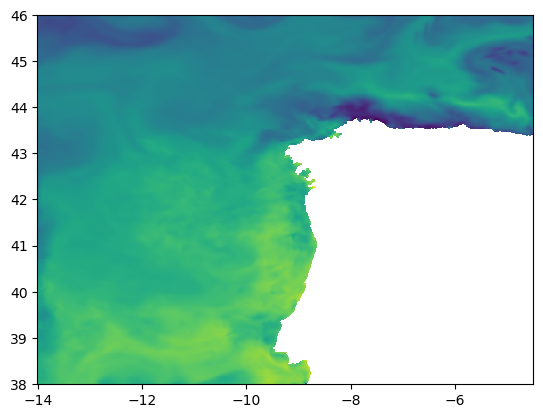

In [8]:
plt.pcolor(lon,lat,T)

Ahora localizamos la longitud y la latitud de la boya de Cies:

In [9]:
# Coordenadas de la boya de Cies
longitud = -8 - 53.59/60
latitud  = 42 + 10.69/60

I = np.argmin(np.abs(lon - longitud))
J = np.argmin(np.abs(lat - latitud))

print('Boya: (%f, %f) Modelo: (%f, %f)' % (longitud, latitud, lon[I], lat[J]))

Boya: (-8.893167, 42.178167) Modelo: (-8.900000, 42.180000)


In [10]:
# Las fechas dan problema. Hay que recodificar la columna "ocean_time" antes de exportar a Pandas:
seleccion = filtrado.filter( (col('lon_rho')==lon[I]) & (col('lat_rho')==lat[J])).withColumn("ocean_time", date_format("ocean_time", "yyyy-MM-dd HH:mm:ss")).toPandas()

seleccion.set_index('ocean_time', inplace=True)
seleccion.index = seleccion.index.astype('datetime64[ns]')

seleccion.sort_index(inplace=True)

In [11]:
seleccion

,lon_rho,lat_rho,temp
ocean_time,,,
2022-01-01 00:00:00,-8.9,42.18,14.257157
2022-01-01 01:00:00,-8.9,42.18,14.229171
2022-01-01 02:00:00,-8.9,42.18,14.233514
2022-01-01 03:00:00,-8.9,42.18,14.229077
2022-01-01 04:00:00,-8.9,42.18,14.224672
...,...,...,...
2022-12-31 19:00:00,-8.9,42.18,15.842854
2022-12-31 20:00:00,-8.9,42.18,15.840614
2022-12-31 21:00:00,-8.9,42.18,15.844250


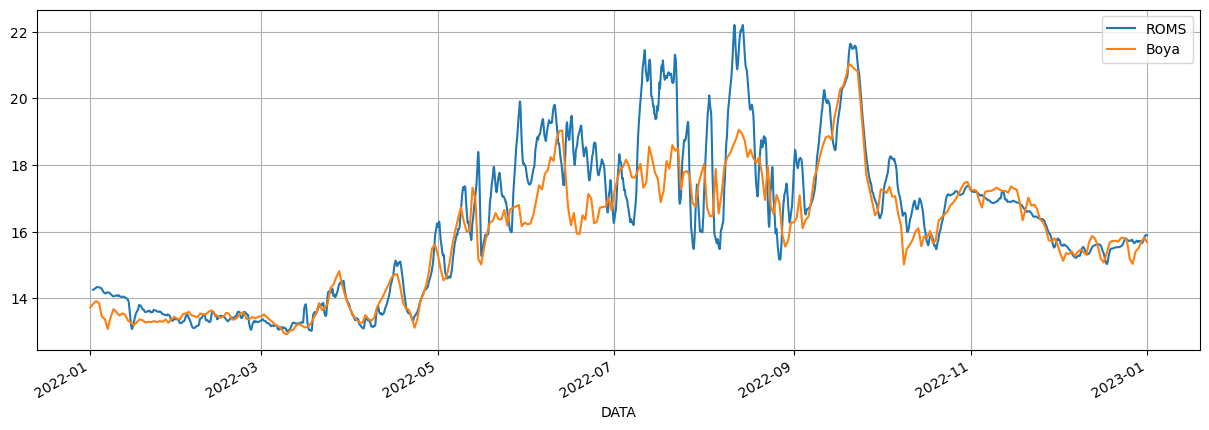

In [12]:
plt.figure(figsize=(15,5))
seleccion.temp.rolling(24).mean().plot(legend=True)
cies[cies.index<='2023-01-01'].VALOR.plot(legend=True)
plt.legend(['ROMS','Boya'])
plt.grid()

# Validacion del ROMS con termosalinometros

In [13]:
onehealth.describe('C8Z3i4pPj9Gz8Pw')

Valor,Unidad,Tipo,Descripción
longitude,degrees_east,double,A coordenada lonxitudinal do punto de datos.
latitude,degrees_north,double,A coordenada latitudinal do punto de datos.
t090c,degree_Celsius,double,"Temperatura en graos Celsius, medida polo sensor a 90 cm."
sal00,1e-3,double,Salinidade da auga.
flscufa,unknown,string,"Fluorescencia, unha medida da concentración de clorofila ou fitoplancto na auga."
cdomfltc0,unknown,string,Colored Dissolved Organic Matter fluorescence. Indica a presenza de compostos orgánicos na auga.
turbfltc0,unknown,string,Medida da turbidez ou nebulosidad da auga causada por un gran número de partículas individuais.
timem,seconds,double,"Tempo en segundos, presumiblemente desde unha época determinada."
flag,,int,Indicador ou bandeira para control de calidade ou erros.
fecha,,timestamp,Data e hora da observación.


In [14]:
lura = onehealth.load('C8Z3i4pPj9Gz8Pw').select(['fecha','longitude','latitude','t090c','sal00']).withColumn("fecha", date_format("fecha", "yyyy-MM-dd HH:mm:ss")).toPandas()

In [15]:
lura = lura[(lura.fecha>='2022-01-1') & (lura.fecha<'2023-01-1')]

In [16]:
lura

,fecha,longitude,latitude,t090c,sal00
526,2022-01-14 07:48:47,-8.38566,43.36786,11.8902,33.8785
527,2022-01-14 07:49:11,-8.38566,43.36784,11.8942,33.8821
528,2022-01-14 07:51:17,-8.38566,43.36784,11.9037,33.8837
529,2022-01-14 07:52:32,-8.38566,43.36784,11.9061,33.8847
530,2022-01-14 07:56:41,-8.38464,43.36428,12.4488,34.2295
...,...,...,...,...,...
423454,2022-12-27 11:33:35,-8.38572,43.36790,13.6424,32.0211
423455,2022-12-27 11:33:38,-8.38572,43.36790,13.6409,32.0195
423456,2022-12-27 11:33:41,-8.38572,43.36790,13.6409,32.0156
423457,2022-12-27 11:33:44,-8.38572,43.36790,13.6355,32.0014


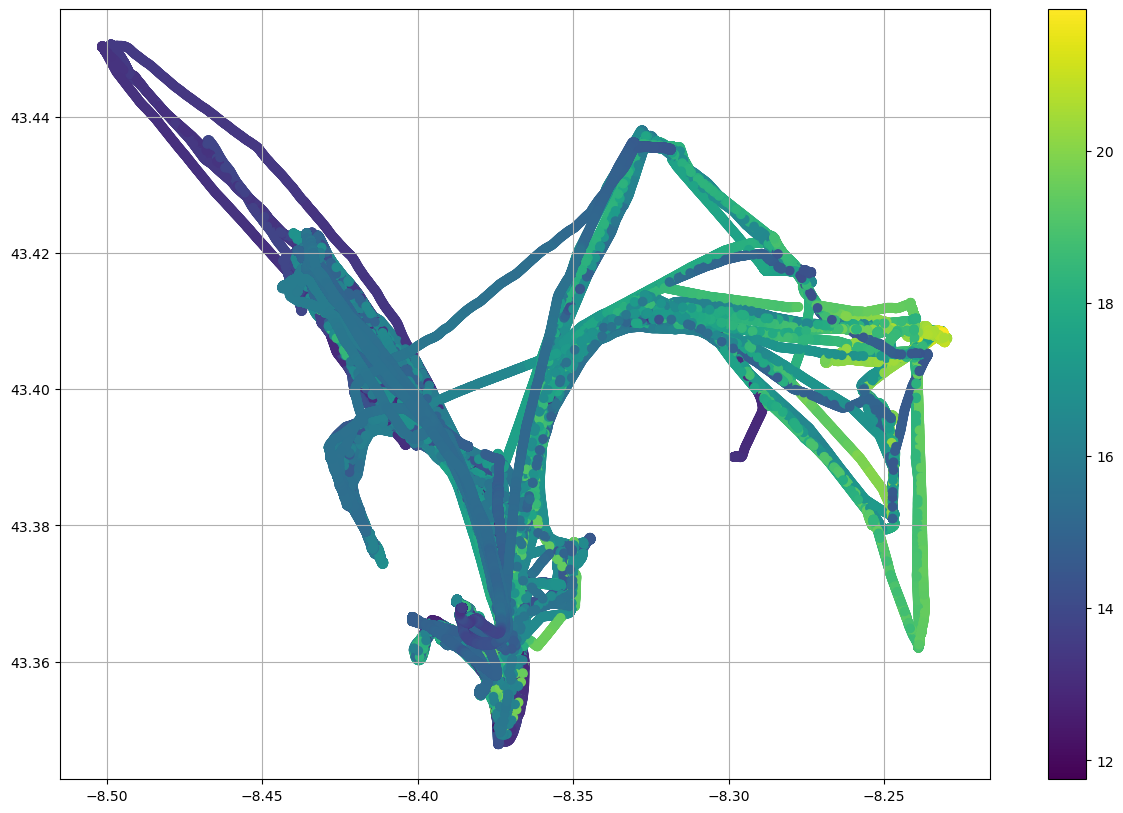

In [17]:
plt.figure(figsize=(15,10))
plt.scatter(lura.longitude,lura.latitude,c=lura.t090c)
plt.colorbar()
plt.grid()

# Procesado de grandes cantidades de datos

In [18]:
from pyspark.sql.functions import col, expr, date_format, dayofyear, min, max, avg, stddev
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [19]:
%%time
df = onehealth.load('DmTYeZYxD5wfRax')

CPU times: user 16 ms, sys: 1.54 ms, total: 17.5 ms
Wall time: 27.7 s


Vamos a calcular una climatologia de la temperatura superficial del modelo. Para ello inicialmente haremos un filtrado de los datos para quedarnos con los datos espaciales de temperatura superficial de las primeras 24h de prediccion:

In [20]:
filtrado = df.filter( (col('depth')==0) & (col('step')<=23) ).select(['ocean_time','lon_rho','lat_rho','temp'])
filtrado.show()

+-------------------+-------+-------+------------------+
|         ocean_time|lon_rho|lat_rho|              temp|
+-------------------+-------+-------+------------------+
|2018-05-19 10:00:00|  -14.0|   38.0|15.710969924926758|
|2018-05-19 10:00:00| -13.98|   38.0| 15.70999813079834|
|2018-05-19 10:00:00| -13.96|   38.0|15.693028450012207|
|2018-05-19 10:00:00| -13.94|   38.0|15.714655876159668|
|2018-05-19 10:00:00| -13.92|   38.0|15.715215682983398|
|2018-05-19 10:00:00|  -13.9|   38.0|15.722404479980469|
|2018-05-19 10:00:00| -13.88|   38.0|15.728519439697266|
|2018-05-19 10:00:00| -13.86|   38.0|15.746536254882812|
|2018-05-19 10:00:00| -13.84|   38.0|15.753320693969727|
|2018-05-19 10:00:00| -13.82|   38.0| 15.76167106628418|
|2018-05-19 10:00:00|  -13.8|   38.0|15.767802238464355|
|2018-05-19 10:00:00| -13.78|   38.0|15.775607109069824|
|2018-05-19 10:00:00| -13.76|   38.0|15.780366897583008|
|2018-05-19 10:00:00| -13.74|   38.0|15.786251068115234|
|2018-05-19 10:00:00| -13.72|  

A continuacion definimos una nueva columna (dia del año) que usaremos como indice para agrupar junto con los valores de longitud y latitud de cada nodo. Esta consulta es la mas pesada de todo el procedimiento y conllevaria una gran cantidad de operaciones. En Spark (lazy computation) el calculo no se realizara hasta que accedamos a algunos de los valores del dataframe:

In [21]:
clima = (filtrado
    .withColumn("dia", dayofyear(col("ocean_time")))
    .groupBy(['dia','lon_rho','lat_rho'])
    .agg(
        avg("temp").alias('media'),
        stddev("temp").alias('std_temp')
    )
)         

# Serie temporal de clima de temperatura superficial

Inicialemente buscaremos un punto de la malla mas cercano a la boya de Cies:

In [22]:
# Coordenadas de la boya de Cies
longitud = -8 - 53.59/60
latitud  = 42 + 10.69/60

I = np.argmin(np.abs(lon - longitud))
J = np.argmin(np.abs(lat - latitud))

print('Boya: (%f, %f) Modelo: (%f, %f)' % (longitud, latitud, lon[I], lat[J]))

Boya: (-8.893167, 42.178167) Modelo: (-8.900000, 42.180000)


Filtramos el clima de temperatura superficial con la longitud y laltitud obtenida en el paso anterior:

In [23]:
seleccion = clima.filter( (col('lon_rho')==lon[I]) & (col('lat_rho')==lat[J]))

A continuacion, cuando efectuamos la conversion a Pandas es cuando se realiza el grueso de los calculos:

In [24]:
serie = seleccion.toPandas()
serie.set_index('dia',inplace=True)
serie.sort_index(inplace=True)

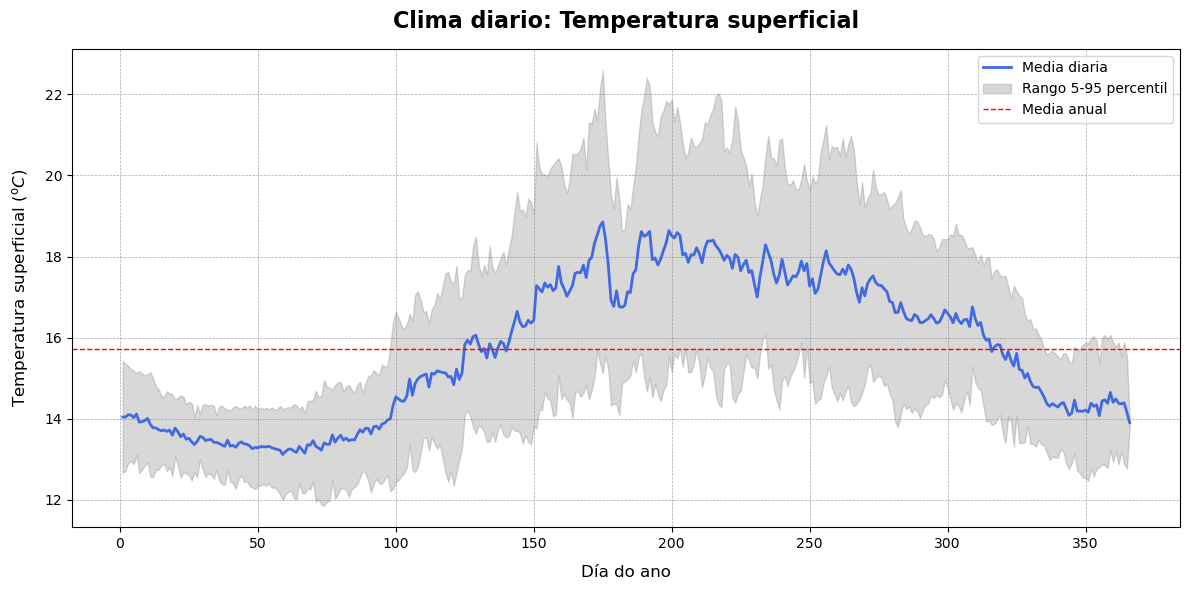

In [25]:
# Calcular los percentiles 5 y 95
percentil_5 = serie.media - 1.645 * serie.std_temp  # Aproximación basada en 1.645*std_dev para 90% de cobertura
percentil_95 = serie.media + 1.645 * serie.std_temp

plt.figure(figsize=(12, 6))

# Graficar la columna media
serie.media.plot(color='royalblue', linewidth=2, label='Media diaria')

# Agregar banda de percentiles
plt.fill_between(
    serie.index, percentil_5, percentil_95,
    color='gray', alpha=0.3, label='Rango 5-95 percentil'
)

# Agregar una cuadrícula con un estilo más sutil
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Título y etiquetas con mejor formato
plt.title('Clima diario: Temperatura superficial', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Día do ano', fontsize=12, labelpad=10)
plt.ylabel('Temperatura superficial ($^\mathrm{o}C$)', fontsize=12, labelpad=10)

# Límites automáticos ajustados
plt.tight_layout()

# Agregar línea de referencia para la media anual
plt.axhline(serie.media.mean(), color='red', linestyle='--', linewidth=1, label='Media anual')

# Agregar leyenda
plt.legend()

# Mapa del clima de la temperatura superficial

In [26]:
seleccion = clima.filter( (col('dia')==200) )

In [27]:
df = seleccion.toPandas()

El paso siguiente es tremendamente importante. Es necesario ordenar los datos para poder reconstruir la matriz. Si los datos estan proyectados es imperativo trabajar con las coordenadas proyectadas y hacer la ordenacion utilizandolas. En este caso, no estan proyectadas y seguimos trabajando con coordenadas esfericas como en casos anteriores. 

In [28]:
df.sort_values(by=['lat_rho','lon_rho'],inplace=True)
Tclim  = df.media.values.reshape((401,476))

In [29]:
import matplotlib.pyplot as plt
import numpy as np

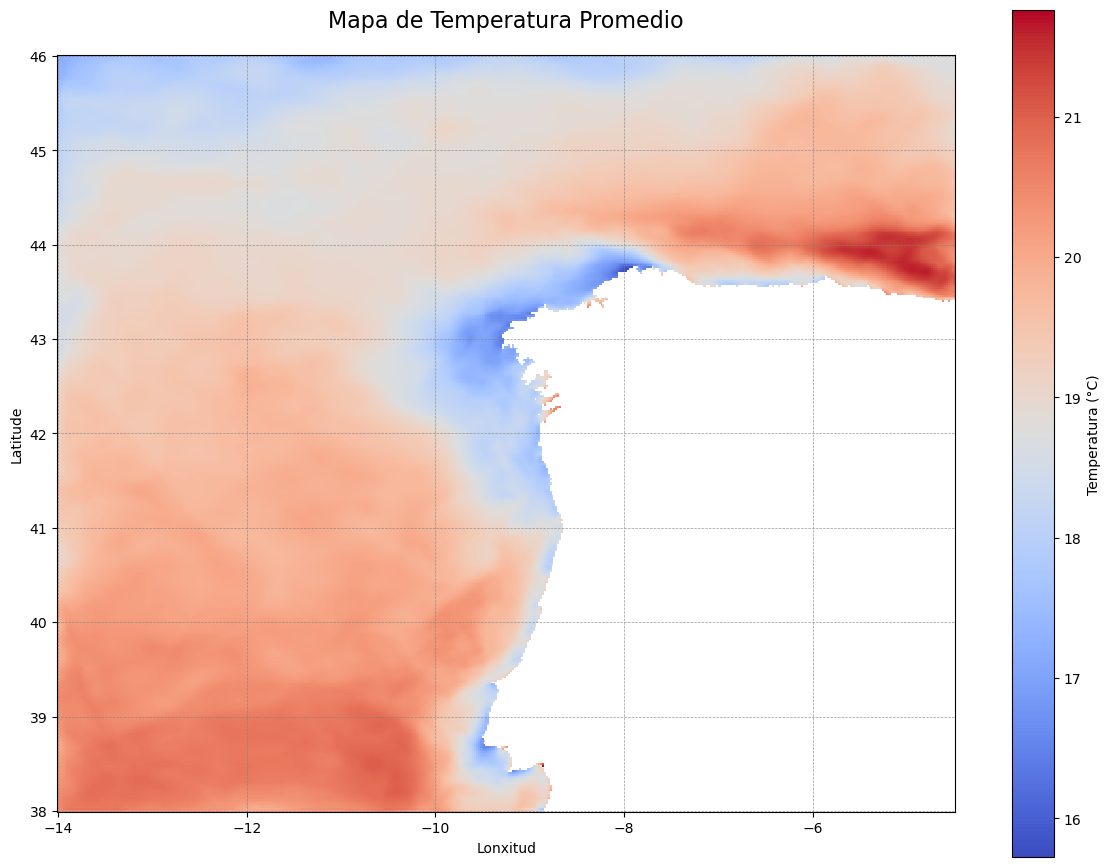

In [30]:
fig, ax = plt.subplots(figsize=(12, 9))

# Mapa de colores
mesh = ax.pcolormesh(
    lon,
    lat,
    Tclim,
    cmap="coolwarm",
    shading="auto"
)

# Barra de colores
cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="vertical"
)
cbar.set_label("Temperatura (°C)")

# Cuadrícula
ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    color="gray",
    alpha=0.8
)

# Etiquetas
ax.set_xlabel("Lonxitud")
ax.set_ylabel("Latitude")

# Título
ax.set_title(
    "Mapa de Temperatura Promedio",
    fontsize=16,
    pad=20
)

# Mantener proporciones geográficas razonables
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()